In [5]:
import numpy as np
import matplotlib.pyplot as plt
import expansion as ex
import ODESolve_slow as ODE
from constants import GF, gA, me, hbar, dmnp, mpl, mN, zeta3
import weakrates as weak
import expansion as ex


In [6]:
def f(a,y,p):
    
    T , t , Yp , Yn , eta = y
    der = np.zeros(5)

    der[0] = -(3*a**2*ex.sth(T))/(a**3*ex.dsthdT(T))
    der[1] = (1/a)*((8*np.pi*ex.ptot(T,a))/(3*(mpl)**2))**(1/2)
    der[2] = (Yn*weak.Nnptot(T,a)-Yp*weak.Npntot(T,a))*der[1]
    der[3] = (-Yn*weak.Nnptot(T,a)+Yp*weak.Npntot(T,a))*der[1]
    der[4] = -3*eta*((1/T)*der[0]+(1/a))

    return der

In [7]:
a0 = 0.1    
y0 = np.array([10,0,0,0,(6.1e-10)*(11/4)],dtype=np.double)
y0[2] = (1+(weak.Npntot(y0[0],a0))/(weak.Nnptot(y0[0],a0)) )**(-1)
y0[3] = 1- y0[2]
p=None
dx0=0.001

N_step = 1000
dN = 2
x_final = 100




a, y, dx, done = ODE.ODEOneRun(a0, y0, dx0, p, N_step, dN, x_final)
print(done)

True


In [10]:
g = np.array([2, 2 ,3, 2, 2, 1, 4, 4, 3], dtype=np.double)
B = np.array([0, 0, 2.22, 8.48, 7.72, 28.3, 37.6, 39.25, 31.99], dtype=np.double)
Z = np.array([1, 0, 1, 1, 2, 2, 4, 3, 3], dtype=np.double)
A = np.array([1, 1, 2, 3, 3, 4, 7, 7, 6], dtype=np.double)

In [11]:
print(y[4])
print(y[0])


[9.95533319e+00 1.00803446e+17 5.32411950e-01 4.67588050e-01
 1.67749728e-09]
[1.0000000e+01 0.0000000e+00 5.3228004e-01 4.6771996e-01 1.6775000e-09]


In [13]:
def nse(T, eta, Yp, Yn):
  
    nse=np.zeros(9)
    
    for i in range(len(nse)):
        nB = eta*(3/2)*zeta3*T**3
        epsilon=(1/2)*((2*np.pi)/mN*T)**(3/2)*nB
        nse[i]=(1/2)*Yp**Z[i]*Yn**(A[i]-Z[i])*g[i]*A[i]**(3/2)*epsilon**(A[i]-1)*np.exp(B[i]/T)
        
    return nse

print (nse(1, 1, 1, 1))

[1.00000000e+00 1.00000000e+00 1.92457267e-02 6.07613918e-03
 2.84160630e-03 9.33870736e+02 1.13118972e-02 5.89008205e-02
 5.00288100e-02]


In [14]:
Y=np.zeros((9,len(a)))

for i in range(len(a)):
    
    Y[:,i] = nse(y[i,0] , y[i,4] , y[i,2] , y[i,3])

/var/folders/wh/zy977ds93ps0947h9g20l8ch0000gr/T/ipykernel_69335/600221019.py:8: RuntimeWarning: overflow encountered in exp
  nse[i]=(1/2)*Yp**Z[i]*Yn**(A[i]-Z[i])*g[i]*A[i]**(3/2)*epsilon**(A[i]-1)*np.exp(B[i]/T)


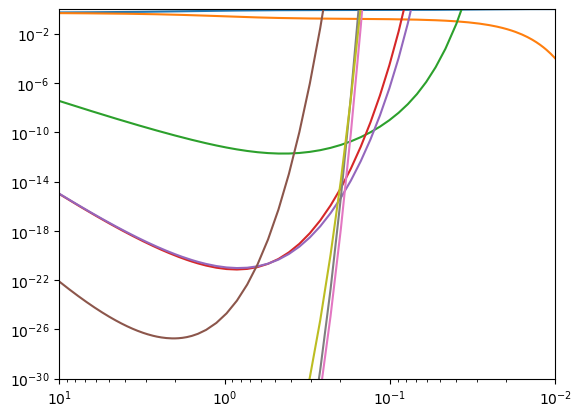

In [15]:
Tcm = np.zeros(len(a))
for i in range(len(Tcm)):
    Tcm[i]=1/a[i]

plt.figure()
for i in range(9):
    plt.loglog(Tcm,Y[i,:])
    plt.ylim(1e-30,1)
    plt.xlim(10,1e-2)

In [16]:
P_INDEX = 0
N_INDEX = 1
H2_INDEX = 2
H3_INDEX = 3
HE3_INDEX = 4
HE4_INDEX = 5
BE7_INDEX = 6
LI7_INDEX = 7
LI6_INDEX = 8

In [17]:

def sep(z):
    return z[0], z[1], z[2], z[3:]
T,t,eta,A = sep(np.arange(12))


In [18]:
def depvar(T,t,eta,A):
    return np.concatenate((np.array([T,t,eta]), A))

In [19]:
print(depvar(T, t, eta, A))

[ 0  1  2  3  4  5  6  7  8  9 10 11]


In [37]:

def f(a,y,p):
    T, t, eta, A = sep(y)
    der=np.zeros(3)
    d=np.zeros(9)

    der[0] = -(3*a**2*ex.sth(T))/(a**3*ex.dsthdT(T))
    der[1] = (1/a)*((8*np.pi*ex.ptot(T,a))/(3*(mpl)**2))**(1/2)
    der[2] = -3*eta*((1/T)*der[0]+(1/a))

    d[P_INDEX] += A[N_INDEX]*weak.Nnptot(T,a)
    d[N_INDEX] -= A[P_INDEX]*weak.Npntot(T,a)
    d[H2_INDEX] = 0
    d[H3_INDEX] = 0
    d[HE3_INDEX] = 0
    d[HE4_INDEX] = 0
    d[BE7_INDEX] = 0
    d[LI7_INDEX] = 0
    d[LI6_INDEX] = 0

    return sep(der[0], der[1], der[2], z)

In [ ]:
a0 = 0.1    
y0 = np.array([10,0,0,0,(6.1e-10)*(11/4)],dtype=np.double)
y0[2] = (1+(weak.Npntot(y0[0],a0))/(weak.Nnptot(y0[0],a0)) )**(-1)
y0[3] = 1- y0[2]
p=None
dx0=0.001

N_step = 1000
dN = 2
x_final = 100




a, y, dx, done = ODE.ODEOneRun(a0, y0, dx0, p, N_step, dN, x_final)
print(done)